In [73]:
# PART 1: DATA COLLECTION: FROM CELLS 1-7 We will gather the data for the S%P

In [74]:
import yfinance as yf # Calls the yahoo finance API to download daily stock and index prices

In [75]:
sp500 = yf.Ticker("^GSPC") # Downloads the price history for S&P 500

In [76]:
sp500 = sp500.history(period="max") # requesting every single piece of historical price data available for that index from the Yahoo Finance servers.

In [77]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-09-28 00:00:00-04:00,7721.700195,7724.149902,7666.600098,7683.689941,5129710000,0.0,0.0
2026-09-29 00:00:00-04:00,7699.600098,7699.600098,7653.549805,7670.839844,5023590000,0.0,0.0
2026-09-30 00:00:00-04:00,7688.990234,7722.879883,7651.540039,7651.540039,4276550000,0.0,0.0


In [78]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-09-21 00:00:00-04:00', '2026-09-22 00:00:00-04:00',
               '2026-09-23 00:00:00-04:00', '2026-09-24 00:00:00-04:00',
               '2026-09-25 00:00:00-04:00', '2026-09-28 00:00:00-04:00',
               '2026-09-29 00:00:00-04:00', '2026-09-30 00:00:00-04:00',
               '2026-10-01 00:00:00-04:00', '2026-10-02 00:00:00-04:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=24806, freq=None)

<Axes: xlabel='Date'>

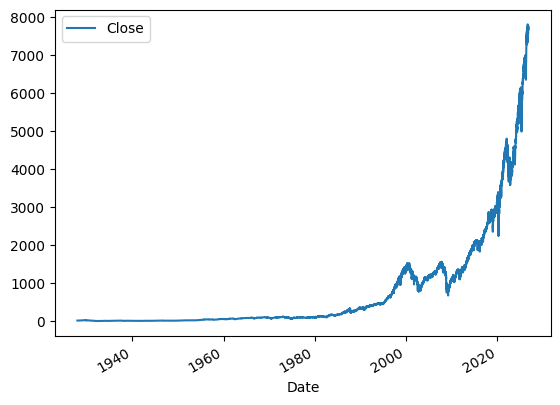

In [79]:
sp500.plot.line(y="Close", use_index=True) # Creates a plot where X is the dates, and y is the closing prices of the S&P 500

In [80]:
del sp500["Dividends"]
del sp500["Stock Splits"]    # These columns are more for indivisual stocks not the index like for S&P, so we don't need them

In [81]:
# PART 2: THE CODE FOR DEFINING THE "TARGET"

In [82]:
# So we will write code to see the DAYS where the stock is up, will it stay up for the next coming weeks?

In [83]:
sp500["Tomorrow"] = sp500["Close"].shift(-1) #Line used to predict "Tomorrow's" Price

In [84]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-09-28 00:00:00-04:00,7721.700195,7724.149902,7666.600098,7683.689941,5129710000,7670.839844
2026-09-29 00:00:00-04:00,7699.600098,7699.600098,7653.549805,7670.839844,5023590000,7651.540039
2026-09-30 00:00:00-04:00,7688.990234,7722.879883,7651.540039,7651.540039,4276550000,7666.450195


In [85]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int) # The target will be if the "Tomorrow's" Price will be greater than todays price, which indicates that it is growing which is what we want

In [86]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-09-28 00:00:00-04:00,7721.700195,7724.149902,7666.600098,7683.689941,5129710000,7670.839844,0
2026-09-29 00:00:00-04:00,7699.600098,7699.600098,7653.549805,7670.839844,5023590000,7651.540039,0
2026-09-30 00:00:00-04:00,7688.990234,7722.879883,7651.540039,7651.540039,4276550000,7666.450195,1


In [87]:
sp500 = sp500.loc["1990-01-01":].copy()  # Only take data after 1990. Also use .copy so u dont get a pandas setting with .copy warning

In [88]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-09-28 00:00:00-04:00,7721.700195,7724.149902,7666.600098,7683.689941,5129710000,7670.839844,0
2026-09-29 00:00:00-04:00,7699.600098,7699.600098,7653.549805,7670.839844,5023590000,7651.540039,0
2026-09-30 00:00:00-04:00,7688.990234,7722.879883,7651.540039,7651.540039,4276550000,7666.450195,1


In [89]:
# PART 3: First Machine Learning Model: We are trying to see if a computer can find a pattern between today’s raw price numbers and tomorrow’s movement.

In [90]:
from sklearn.ensemble import RandomForestClassifier # RandomForestClassifier is a machine learning model. Used RandomForest because it can pick up non linear relationships, which is what we need for prediction stock prices

model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)  # Change this around to maximize the accuracy

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors =["Close", "Volume", "Open", "High", "Low"]

model.fit(train[predictors], train["Target"]) # Training all of the predictors above



,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [91]:
from sklearn.metrics import precision_score # Basically % of the time the market acc went up after we predicted that it would go up (when it was a 1)

preds = model.predict(test[predictors]) # Generating Predictions here

In [92]:
import pandas as pd
preds = pd.Series(preds, index = test.index) # Converted the prdiction above from array to series

In [93]:
preds

Date
2026-05-12 00:00:00-04:00    0
2026-05-13 00:00:00-04:00    0
2026-05-14 00:00:00-04:00    0
2026-05-15 00:00:00-04:00    0
2026-05-18 00:00:00-04:00    0
                            ..
2026-09-28 00:00:00-04:00    0
2026-09-29 00:00:00-04:00    0
2026-09-30 00:00:00-04:00    0
2026-10-01 00:00:00-04:00    0
2026-10-02 00:00:00-04:00    0
Length: 100, dtype: int64

In [94]:
precision_score(test["Target"], preds)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


0.0

In [95]:
# Plot the predictions

In [96]:
combined = pd.concat([test["Target"], preds], axis=1) # Concatating actual vs predicted values

<Axes: xlabel='Date'>

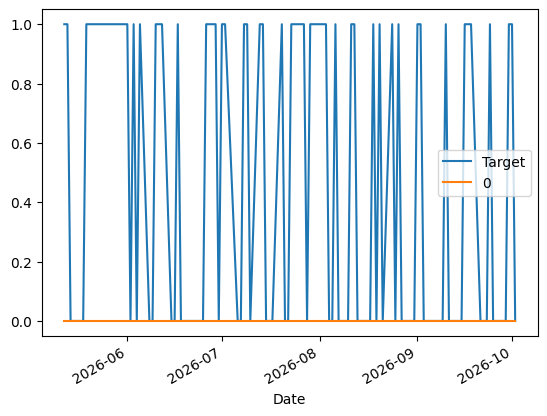

In [97]:
combined.plot()

In [98]:
# PART 4: BackTesting System: Instead of testing on just 100 days, we test on 30 years of data to see if the model actually works in real-world conditions. EXAMPLE: It starts at year 10 (2500 days). It uses years 1–10 to predict year 11.

In [99]:
def predict (train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [100]:
def backtest(data, model, predictors, start = 2500, step = 250): # The start value is for 10 years worth testing. BC every trading year has 250 days. And step 250 shows you are going through each trading year

    all_predictions = []   # So we will take the first 10 years, and predicth the 11th, then the 11 years and predict 12th, etc

    for i in range (start, data.shape[0], step):
        train = data.iloc[0:i].copy() # The "10 Years"
        test = data.iloc[i:(i+step)].copy() # The "11th" Year
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
        return pd.concat (all_predictions)
    

In [101]:
predictions = backtest(sp500, model, predictors)

In [102]:
predictions["Predictions"].value_counts()

Predictions
0    237
1     13
Name: count, dtype: int64

In [103]:
precision_score(predictions["Target"], predictions["Predictions"])

0.46153846153846156

In [104]:
predictions["Target"].value_counts() / predictions.shape[0]

Target
0    0.516
1    0.484
Name: count, dtype: float64

In [105]:
# PART 5: Comparing Prices Strategy ML Model

In [106]:
horizons = [2,5,60,250,1000] # So basically comparing prices of today vs the last 2 days, last 5 days, 50, 250, etc.
new_predictors = []

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"] # Doing this to see if the stock has went up for every of those horizon days

    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"] # Example: In a 5-day horizon, a sum of 3 means the market went up on 3 out of the last 5 days.
    
    new_predictors += [ratio_column, trend_column] 

In [107]:
sp500 = sp500.dropna()

In [108]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-25 00:00:00-04:00,7709.859863,7752.069824,7693.080078,7743.410156,4499180000,7683.689941,0,1.002543,1.0,1.000883,2.0,1.016428,28.0,1.088503,136.0,1.390034,546.0
2026-09-28 00:00:00-04:00,7721.700195,7724.149902,7666.600098,7683.689941,5129710000,7670.839844,0,0.996129,1.0,0.995248,1.0,1.008146,27.0,1.079488,135.0,1.378299,546.0
2026-09-29 00:00:00-04:00,7699.600098,7699.600098,7653.549805,7670.839844,5023590000,7651.540039,0,0.999163,0.0,0.996003,1.0,1.006167,26.0,1.077088,134.0,1.375009,545.0


In [109]:
# PART 6: Only trade if you are 60% sure that the stock will go up

In [110]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [111]:
def predict (train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors]) [:,1]  # Will instead give the probability if the stock price will go up or down 
    preds[preds >= .6] = 1
    preds[preds < .6] = 0  # This will reduce the total num of trading days, but will increase the probablility the prices will go up on the days. BC we arent gonna be trading every day 
    
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [112]:
predictions = backtest(sp500, model, new_predictors)

In [113]:
predictions ["Predictions"].value_counts()

Predictions
0.0    207
1.0     43
Name: count, dtype: int64

In [114]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5813953488372093

In [115]:
# PART 7: EXTRA STUFF ADDED SEPERATE FROM TUTORIAL. :::>  ONLY THIS IS NEEDED >>> ADDED FEAR MOMENTUM AND INTEREST RATES TO INCREASE THE RATE

In [116]:
# 

In [117]:
import pandas as pd
import yfinance as yf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score

# PART 1: Load the Data 

print("1. Loading Data...")
try:
    # Try/Except block to download the S%P 500 Index (GSPC)
    sp500 = yf.Ticker("^GSPC").history(period="max")
    if sp500.empty: raise ValueError("Empty Data")
    print("   > Loaded ^GSPC")
except:
    # Fallback to SPY ETF if Index fails
    print("   > ^GSPC failed. Switching to SPY...")
    sp500 = yf.Ticker("SPY").history(period="max")
    print("   > Loaded SPY")

# Delete all the Data before 1990, so we only take in the recent market after 1990
sp500 = sp500.loc["1990-01-01":].copy()
if "Dividends" in sp500.columns: del sp500["Dividends"] # When you download data for an individual stock (like Apple), Yahoo includes a "Dividends" column. However, the S&P 500 is an Index, not a single stock, so this column is usually empty (filled with zeros).
if "Stock Splits" in sp500.columns: del sp500["Stock Splits"] # Same as above here

sp500["Tomorrow"] = sp500["Close"].shift(-1) # Take Tomorrow's price and move it onto "today's" row
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int) # Sets our goal. If tomorrow is higher, the target is $1$. If lower, it is $0$.
sp500.index = sp500.index.tz_localize(None) # Removing TimeZone Info to prevent errors when we merge the VIX and Interest Rate data later

# --- PART 2: CALCULATING INDICATORS --- giving the AI "Context" so it understands if a price is high or low.
print("2. Calculating Technicals...")
horizons = [2, 5, 60, 250, 1000]
rolling_predictors = []

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean() # Calculates the average closing price for the current time window.
    ratio_col = f"Close_Ratio_{horizon}"
    sp500[ratio_col] = sp500["Close"] / rolling_averages["Close"] # IS the price today higher or lower than the average price of last year?
    trend_col = f"Trend_{horizon}"
    sp500[trend_col] = sp500["Target"].shift(1).rolling(horizon).sum() # counts how many days the market went up in that window.
    rolling_predictors += [ratio_col, trend_col] # Adds these new calculations to the list of variables the AI will study.

# PART 3: Add VIX (Fear Index)
try:
    vix = yf.Ticker("^VIX").history(period="max") # Uses Yahoo Finance to download every piece of historical data available for the VIX (the Fear Index).
    vix.index = vix.index.tz_localize(None) # Removes the Time Zone Info so it matces teh S%P 500 data bc we removed time zones for that aswell
    vix = vix[["Close"]].rename(columns={"Close": "VIX_Close"}) # Rename so it does not get confused with the S%P 
    sp500 = sp500.join(vix).ffill()
except:
    pass

# PART 4: Add RSI (Relitave Strength Index) >> Tells the AI if prices are moving up too fast (becoming a "bubble") or dropping too fast.
def calculate_rsi(data, window=14): # Use 14 day window for industry standard
    delta = data.diff() # Calculates the change in price, iF price was 100 yesterday and 102 today, Delta = +2
    up = delta.clip(lower=0) # creates a list of only the Gains. If the price dropped, it just records a 0.
    down = -1 * delta.clip(upper=0) # Creates a list of only the Losses
    ema_up = up.ewm(com=window-1, adjust=False).mean() # average gain over the last 14 days, givibg more importance to the recent days
    ema_down = down.ewm(com=window-1, adjust=False).mean() # Same as above but for losses
    rs = ema_up / ema_down # Ratio of the Top, Calculates if teh gains are currently more than losses
    return 100 - (100 / (1 + rs)) # final RSI formula, squashes the rs number into a scale between 0 and 100.

sp500["RSI"] = calculate_rsi(sp500["Close"]) # applies the function to your S&P 500 closing prices and creates the new "RSI" column for the AI to study.

# --- PART 5 ADD INTEREST RATES (TNX)
tnx_predictors = [] # store the names of the new interest rate columns we are about to create.
try:
    tnx = yf.Ticker("^TNX").history(period="max") # Downloads the complete history for the 10-Year Treasury Yield (^TNX).
    tnx.index = tnx.index.tz_localize(None) # Removeing Time zone data to align with S%P 500 table
    tnx = tnx[["Close"]].rename(columns={"Close": "TNX_Close"}) # Rename it to TNX_CLOSE
    sp500 = sp500.join(tnx).ffill() # Joins the interest rates into the master spreadsheet.
    
    for horizon in horizons:
        rolling_avg = sp500["TNX_Close"].rolling(horizon).mean() # Calculating average interest rate for the current time window
        ratio_col = f"TNX_Close_Ratio_{horizon}" # Creating a name for the new column, named: "TNX_Close_Ratio_"
        sp500[ratio_col] = sp500["TNX_Close"] / rolling_avg # Getting the ratio is todays interest rate/average, and determining if the rates are rising compared to last year
        tnx_up = (sp500["TNX_Close"] > sp500["TNX_Close"].shift(1)).astype(int) # Creating a list of 1's and 0's (If rate went up or down) 
        trend_col = f"TNX_Trend_{horizon}" # Creating a name for column again
        sp500[trend_col] = tnx_up.rolling(horizon).sum() # Counting the days in that the window interest rates were rising
        tnx_predictors.append(ratio_col) # Adding to list
        tnx_predictors.append(trend_col)
except:
    pass # So if the interest rate fails to download, just skip and keep running 

sp500 = sp500.dropna() # Deletes the very first rows of the dataset (the first 1,000 days) because they don't have enough history to calculate the long-term averages.

# --- 3. FINAL MODEL SETUP (The Winner) ---
# UPDATED: Changed min_samples_split to 100 (Winning Setting)
model = RandomForestClassifier(n_estimators=200, min_samples_split=100, random_state=1) # Builds 200 different decesion trees to vote on the outcome. Forces the model to only learn from patterns that appear in at least 100 days of history, which stops it from "memorizing" lucky flukes.

full_predictors = rolling_predictors + ["RSI"] # Combines every sensor we built (Price Ratios, RSI, VIX, and Interest Rates) into one master list for the AI to study.
if "VIX_Close" in sp500.columns: full_predictors += ["VIX_Close"] # checks if the VIX (Fear Index) was  downloaded and added to the main table earlier. And if it is, adds "VIX_Close" to the master list of things the AI should look at.
if tnx_predictors: full_predictors += tnx_predictors # checks if the interest rate (TNX) list we created is not empty. If interest rate data is available,  adds all the specific rate ratios and trends to the master list.

def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1] # Instead of a "Yes/No" guess, this asks the AI for its probability score (e.g., 0.62 or 62% confidence).
    # UPDATED: Threshold 0.65 (Working Set)
    preds[preds >= 0.65] = 1 # If the confidence is above 65%, it will say to buy (1) and if its lower, it will say not to buy (0)
    preds[preds < 0.65] = 0 # Above
    return pd.concat([test["Target"], pd.Series(preds, index=test.index, name="Predictions")], axis=1)

def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []
    print(f"3. Backtesting on {len(data)} rows...")
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions) # combines the AI's predictions with the actual results (Target) into a neat table so we can see how often the AI was right.
    return pd.concat(all_predictions)

# --- 4. EXECUTION ---
if len(sp500) > 2500: # Making sure about 10 years of data is present
    predictions = backtest(sp500, model, full_predictors)
    score = precision_score(predictions["Target"], predictions["Predictions"]) # This calculates your final grade. It specifically measures Precision: out of all the times the model said "BUY," how many times did the market actually go up?
    
    print("\n" + "="*40)
    print(f"🏆 FINAL MODEL (66% CONFIGURATION)")
    print(f"   Precision Score: {score:.4f} ({score*100:.2f}%)")
    print(f"   Total Trades:    {predictions['Predictions'].sum()}")
    print("="*40)
    
    # Predict Tomorrow
    last_day = sp500.iloc[[-1]][full_predictors]
    prediction_prob = model.predict_proba(last_day)[:,1][0]
    
    print(f"\n🔮 PREDICTION FOR TOMORROW ({sp500.index[-1].date()}):")
    print(f"   Model Confidence: {prediction_prob:.1%} (Requires 65% to Buy)")
    
    if prediction_prob >= 0.65:
        print("   🚀 SIGNAL: BUY")
    else:
        print("   🛑 SIGNAL: DO NOT BUY")
else:
    print("Error: Not enough data.")

1. Loading Data...
   > Loaded ^GSPC
2. Calculating Technicals...
3. Backtesting on 8256 rows...

🏆 FINAL MODEL (66% CONFIGURATION)
   Precision Score: 0.6613 (66.13%)
   Total Trades:    62.0

🔮 PREDICTION FOR TOMORROW (2026-10-02):
   Model Confidence: 53.9% (Requires 65% to Buy)
   🛑 SIGNAL: DO NOT BUY
